# Exploration

## Variable cible

In [2]:
import pandas as pd

In [ ]:
y = pd.read_csv('../../Dataset/Y_train.csv',index_col=0)
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prdtypecode  84916 non-null  int64
dtypes: int64(1)
memory usage: 1.3 MB


In [4]:
if not y.index.is_unique:
    print("Warning: Duplicate indices found!")

In [ ]:
y2 = pd.read_csv('../../Dataset/Y_train.csv')
pd.Series(y.index == y2.index).unique(), y2.index
# L'index de y venant de index_col=0 est normal, donc pas de précaution particulière à prendre à ce sujet.

(array([ True]), RangeIndex(start=0, stop=84916, step=1))

In [84]:
del y2

In [5]:
y.head(15)

,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705
5,2280
6,10
7,2522
8,1280
9,2582


In [6]:
y.prdtypecode.nunique()

27

In [7]:
y.prdtypecode.unique()

array([  10, 2280,   50, 1280, 2705, 2522, 2582, 1560, 1281, 1920, 2403,
       1140, 2583, 1180, 1300, 2462, 1160, 2060,   40,   60, 1320, 1302,
       2220, 2905, 2585, 1940, 1301])

Le graphique de Jessy montre en fait tous les codes produits, pas une liste abrégée ! Le préciser dans le rendu.

In [8]:
y.describe()

,prdtypecode
count,84916.000000
mean,1773.219900
std,788.179885
min,10.000000
25%,1281.000000
50%,1920.000000
75%,2522.000000
max,2905.000000


In [9]:
y.value_counts()

prdtypecode
2583           10209
1560            5073
1300            5045
2060            4993
2522            4989
1280            4870
2403            4774
2280            4760
1920            4303
1160            3953
1320            3241
10              3116
2705            2761
1140            2671
2582            2589
40              2508
2585            2496
1302            2491
1281            2070
50              1681
2462            1421
2905             872
60               832
2220             824
1301             807
1940             803
1180             764
Name: count, dtype: int64

In [10]:
v=y.value_counts(normalize=True).tolist()
v

[0.12022469263742994,
 0.05974139149276932,
 0.05941165386970653,
 0.058799283998304204,
 0.05875217862358095,
 0.057350793725564085,
 0.05622026473220595,
 0.05605539592067455,
 0.05067360685854256,
 0.04655188657025767,
 0.03816712986951811,
 0.03669508690941636,
 0.0325144849027274,
 0.031454613971454146,
 0.030488953789627397,
 0.029535069951481464,
 0.029393753827311696,
 0.029334872108907627,
 0.02437703141928494,
 0.0197960337274483,
 0.016734184370436667,
 0.010268971689669792,
 0.009797917942437232,
 0.00970370719299072,
 0.009503509350416883,
 0.009456403975693627,
 0.008997126572141882]

In [11]:
import numpy as np
ratios = [v[k]/v[-1] for k in range(len(v))]
max(ratios),np.median(ratios),np.std(ratios) #,np.mean(ratios)-np.std(ratios),np.mean(ratios)+np.std(ratios)

(13.362565445026178,
 np.float64(3.4960732984293195),
 np.float64(2.7014821668350457))

Comme l'indique le graphique de Jessy, les catégories sont déséquilibrées : la plupart des catégories sont 3 à 13 fois plus représentées que la plus rare. Les rééquilibrer pourrait améliorer la performance.

## Variables d'entrée

In [12]:
X = pd.read_csv('../../Dataset/X_train.csv',index_col=0)
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 3.2+ MB


In [13]:
if not X.index.is_unique:
    print("Warning: Duplicate indices found!")

In [85]:
X2 = pd.read_csv('../../Dataset/X_train.csv')
pd.Series(X.index == X2.index).unique(), X2.index
# L'index de X venant de index_col=0 est normal, donc pas de précaution particulière à prendre à ce sujet.

(array([ True]), RangeIndex(start=0, stop=84916, step=1))

In [86]:
del X2

In [14]:
X.iloc[:,0].apply(type).unique()

array([<class 'str'>], dtype=object)

In [15]:
X.iloc[:,1].dropna().apply(type).unique()

array([<class 'str'>], dtype=object)

In [16]:
X.head(30)

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786
5,Afrique Contemporaine N° 212 Hiver 2004 - Doss...,NaN,5862738,393356830
6,Christof E: Bildungsprozessen Auf Der Spur,NaN,91920807,907794536
7,Conquérant Sept Cahier Couverture Polypro 240 ...,CONQUERANT CLASSIQUE Cahier 240 x 320 mm seyès...,344240059,999581347
8,Puzzle Scooby-Doo Avec Poster 2x35 Pieces,NaN,4239126071,1325918866
9,Tente Pliante V3s5-Pro Pvc Blanc - 3 X 4m50 - ...,Tente pliante V3S5 Pro PVC 500 gr/m² - 3 x 4m5...,3793572222,1245644185


Les variables imageid et productid semblent inutiles pour la prédiction, et servir juste à associer l'image correspondante lors du preprocessing. Il y a donc essentiellement 3 variables a priori : designation, description, image. Ce petit nombre de variables est une difficulté. En revanche, ces variables semblent avoir un contenu riche et complexe, ce qui offre un potentiel fort si on parvient à les exploiter.

In [17]:
# L'ID est sans doublon, pas de problème.
X.productid.nunique()

84916

In [18]:
# L'ID est sans doublon, pas de problème.
X.imageid.nunique()

84916

### Join

In [19]:
# Join on indexes, according to the documentation of the dataset.
df = X.join(y)
df

,designation,description,productid,imageid,prdtypecode
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705
...,...,...,...,...,...
84911,The Sims [ Import Anglais ],NaN,206719094,941495734,40
84912,Kit piscine acier NEVADA déco pierre Ø 3.50m x...,<b>Description complète :</b><br />Kit piscine...,3065095706,1188462883,2583
84913,Journal Officiel De La Republique Francaise N°...,NaN,440707564,1009325617,2280
84914,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403,1560


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
 4   prdtypecode  84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.9+ MB


### Variables textuelles

Les textes sont en au moins 3 langues (allemand, français, anglais), ce qui peut compliquer le NLP. Rakuten étant une entreprise mondiale, on peut s'attendre à ce que bien plus que 3 langues soient représentées dans le jeu de données. Mais le français semble majoritaire.

In [21]:
print('\n#\n'.join(X.designation.iloc[:100]))

Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design
#
Journal Des Arts (Le) N° 133 Du 28/09/2001 - L'art Et Son Marche Salon D'art Asiatique A Paris - Jacques Barrere - Francois Perrier - La Reforme Des Ventes Aux Encheres Publiques - Le Sna Fete Ses Cent Ans.
#
Grand Stylet Ergonomique Bleu Gamepad Nintendo Wii U - Speedlink Pilot Style
#
Peluche Donald - Europe - Disneyland 2000 (Marionnette À Doigt)
#
La Guerre Des Tuques
#
Afrique Contemporaine N° 212 Hiver 2004 - Dossier Japon / Afrique
#
Christof E: Bildungsprozessen Auf Der Spur
#
Conquérant Sept Cahier Couverture Polypro 240 X 320 Mm 96 Pages 90g Seyès Incolore
#
Puzzle Scooby-Doo Avec Poster 2x35 Pieces
#
Tente Pliante V3s5-Pro Pvc Blanc - 3 X 4m50 - Longueur : 4m50 Largeur : 3 M Blanc H
#
Eames Inspired Sxw Chair - Pink - Black
#
Fauteuil Chesterfield Brenton 100% Cuir De Buffle - Vert Empire
#
Peaceable Kingdom Wheres Bear? The Hide And Find Stacking Block Game For 2 Year Olds
#
Paire De 

Beaucoup d'éléments dans les désignations ne sont pas des mots mais peuvent être quand même pertinents pour la prédiction. Nettoyer les désignations sans nuire à la qualité des prédictions peut être délicat. De nombreuses désignations semblent confuses, difficiles à catégoriser même par un humain.

In [22]:
print('\n#\n'.join(X.dropna().description.iloc[:15]))

PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour GamePad Nintendo Wii U.<br> Pour un confort optimal et une précision maximale sur le GamePad de la Wii U: ce grand stylet hautement ergonomique est non seulement parfaitement adapté à votre main mais aussi très élégant.<br> Il est livré avec un support qui se fixe sans adhésif à l'arrière du GamePad<br> <br> Caractéristiques:<br> Modèle: Speedlink PILOT STYLE Touch Pen<br> Couleur: Bleu<br> Ref. Fabricant: SL-3468-BE<br> Compatibilité: GamePad Nintendo Wii U<br> Forme particulièrement ergonomique excellente tenue en main<br> Pointe à revêtement longue durée conçue pour ne pas abîmer l'écran tactile<br> En bonus : Support inclu pour GamePad<br> <span class="vga_style2"><b></b><br>
#
Luc a des id&eacute;es de grandeur. Il veut organiser un jeu de guerre de boules de neige et s'arranger pour en &ecirc;tre le vainqueur incontest&eacute;. Mais Sophie s'en m&ecirc;le et chambarde tous ses plans...
#
CONQUERANT CLASSIQUE 

Les descriptions aussi sont confuses et parsemées de parasites variés. Leurs tailles sont très variables. L'absence de description pour 35% des données représente aussi une difficulté.

In [ ]:
df['len_designation']=X.designation.apply(len)

In [ ]:
# Les descriptions non NA sont toutes différentes de la chaîne vide '', donc on n'introduit pas d'ambiguïté avec fillna('').
df['len_description']=X.description.fillna('').apply(len)

In [68]:
#TODO? histogram
# Designation lengths (character counts)
df['len_designation'].describe()

count    84916.000000
mean        70.163303
std         36.793383
min         11.000000
25%         43.000000
50%         64.000000
75%         90.000000
max        250.000000
Name: len_designation, dtype: float64

In [ ]:
#TODO? histogram
# description lengths (character counts) (*except* for missing descriptions)
X.description.dropna().apply(len).describe()

count    55116.000000
mean       808.171692
std        805.462153
min          1.000000
25%        259.000000
50%        626.000000
75%       1034.000000
max      12451.000000
Name: description, dtype: float64

In [ ]:
#TODO? histogram
# description lengths (character counts) (*including* missing descriptions)
df['len_description'].describe()

count    84916.000000
mean       524.555926
std        754.893905
min          0.000000
25%          0.000000
50%        231.000000
75%        823.000000
max      12451.000000
Name: len_description, dtype: float64

In [25]:
#TODO? values and plot: moyenne de la longueur de la description par type de produit

70 descriptions font moins de 5 caractères et semblent presque toutes inutiles à la prédiction. Heureusement, elles ne représentent que 0,1% du jeu de données.

In [26]:
# Taille, Nombre de descriptions de cette taille
v=X.description.dropna().apply(len)[X.description.dropna().apply(len) <= 5].value_counts().sort_index()
v

description
1    28
2     9
3    14
4    19
5     7
Name: count, dtype: int64

In [27]:
# Descriptions de moins de 5 caractères
X.description.dropna()[X.description.dropna().apply(len) <= 5].unique()

array(['50PV.', '1989', '...', 'promo', '-', '0', '1985', '1984', 'nc',
       '.', 'Batty', '(1', 'p', 'jeu', '1972.', '&gt;', '1980', 'Buste',
       'Noir', '1969', 'aa', 'Gris', 'B1962', '3323', '1988', '1947',
       '1986', '1991', '1992', '--', '1996', 'table'], dtype=object)

In [28]:
# Nombre et pourcentage de ces descriptions
v.sum(),v.sum()/X.description.dropna().shape[0]

(np.int64(77), np.float64(0.0013970534871906525))

À partir de 6 caractères, les descriptions commencent à sembler utiles à la prédiction : par exemple, "Roman", "Chevet", "Proust".

In [29]:
# Descriptions de 6 caractères
X.description.dropna()[X.description.dropna().apply(len) == 6].unique()

array(['<br />', 'doudou', 'Notice', 'Roman.', 'argent', 'F.215.',
       'Proust', 'Marron', '18X7cm', 'Chevet'], dtype=object)

In [30]:
# Descriptions de 7 caractères
X.description.dropna()[X.description.dropna().apply(len) == 7].unique()

array(['Piano -', '34x29cm', '2259.00', 'Mensuel', '...<br>', 'Commode',
       'RoHS CE', 'Poupon '], dtype=object)

#### Mots les plus fréquents

##### Variable : description

In [31]:
text = ' '.join(X.description.dropna().str.lower())
text[:100]

'pilot style touch pen de marque speedlink est 1 stylet ergonomique pour gamepad nintendo wii u.<br> '

Text(0.5, 1.0, 'Mots les plus fréquents : du numéro 1 au numéro 15')

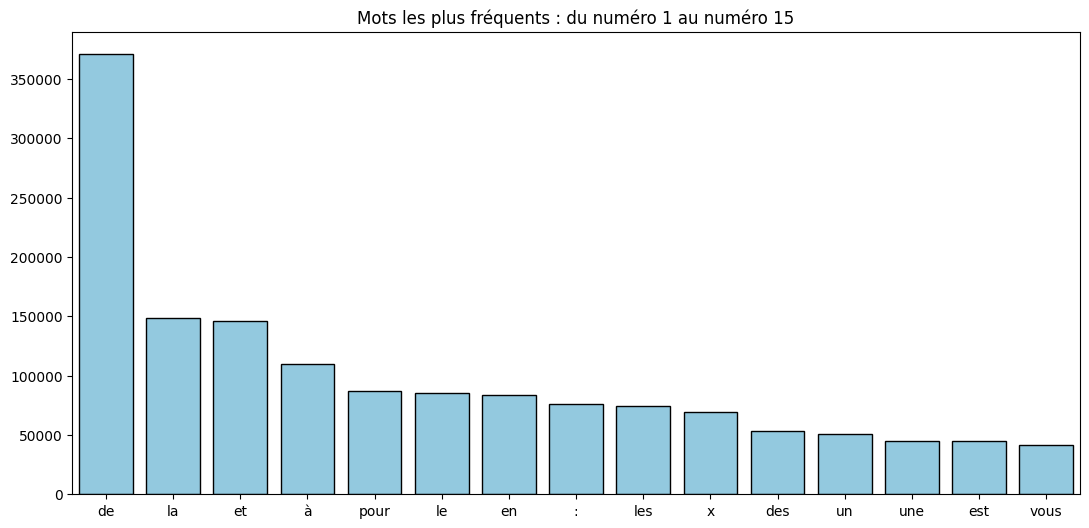

In [32]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

dico = Counter(text.split())
first=0
amount=15
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
freq = [m[1] for m in dico.most_common(first+amount)[first:]]

plt.figure(figsize= (13,6))
sns.barplot(x=mots, y=freq, color='skyblue', edgecolor='black')
plt.title(f'Mots les plus fréquents : du numéro {first+1} au numéro {first+amount}')

In [33]:
first=0
amount=50
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'de | la | et | à | pour | le | en | : | les | x | des | un | une | est | vous | avec | du | - | /> | votre | 1 | / | <br | dans | ou | sur | pas | cm | plus | peut | il | que | au | ne | haute | par | couleur | a | piscine | être | 2 | * | ce | sont | qualité | qui | the | tout | facile | taille'

In [34]:
# Initialiser la variable des mots vides
stop_words = set('p br li ul cm mm X A b H div'.split())
stop_words |= set(mots)
print(stop_words)

{'br', 'des', '*', 'qui', 'ne', 'ce', 'mm', 'du', '<br', 'dans', 'un', 'p', 'qualité', 'ou', 'avec', 'pas', 'facile', '/>', 'taille', 'en', 'A', ':', 'H', 'a', 'piscine', 'les', 'que', '-', 'la', 'votre', 'au', 'li', 'par', 'et', 'vous', 'le', 'haute', 'X', 'une', 'plus', 'cm', 'il', 'être', 'x', 'div', 'de', '1', 'sur', 'ul', 'sont', 'the', '/', 'est', 'pour', 'tout', '2', 'peut', 'b', 'couleur', 'à'}


In [35]:
first=50
amount=300
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'and | /><br | taille: | sans | 3 | plaît | matériel: | dimensions | aux | se | comme | 4 | vos | s&#39;il | enfants | 100% | acier | très | bois | &#43; | l&#39;eau | lumière | cette | to | raison | son | produit | />- | neuf | of | décoration | forfait | non | caractéristiques: | temps | jeu | taie | protection | mode | couleur: | d&#39;un | mesure | batterie | d&#39;une | pouvez | type | main | coussin | (l | 6 | mm | tous | 5 | filtration | l | sac | led | &amp; | sa | bébé | comprend: | contenu | avant | d&#39;eau | design | utiliser | for | pompe | maison | ans | plastique | 1x | hauteur | permettre | couleurs | différence | si | 10 | marque | 1pc | nous | fait | rc | paquet | parfait | elle | surface | durable | ! | blanc | ? | poids | //// | style | m? | forme | d&#39;oreiller | peuvent | cadeau | grande | :</strong> | ces | tissu | couverture | permet | sécurité | également | structure | faire | grand | grâce | facilement | longueur | 8 | voiture | utilisé | </p> | système | m

##### Variable : designation

In [36]:
text = ' '.join(X.designation.str.lower())
text[:100]

'olivia: personalisiertes notizbuch / 150 seiten / punktraster / ca din a5 / rosen-design journal des'

Text(0.5, 1.0, 'Mots les plus fréquents : du numéro 1 au numéro 15')

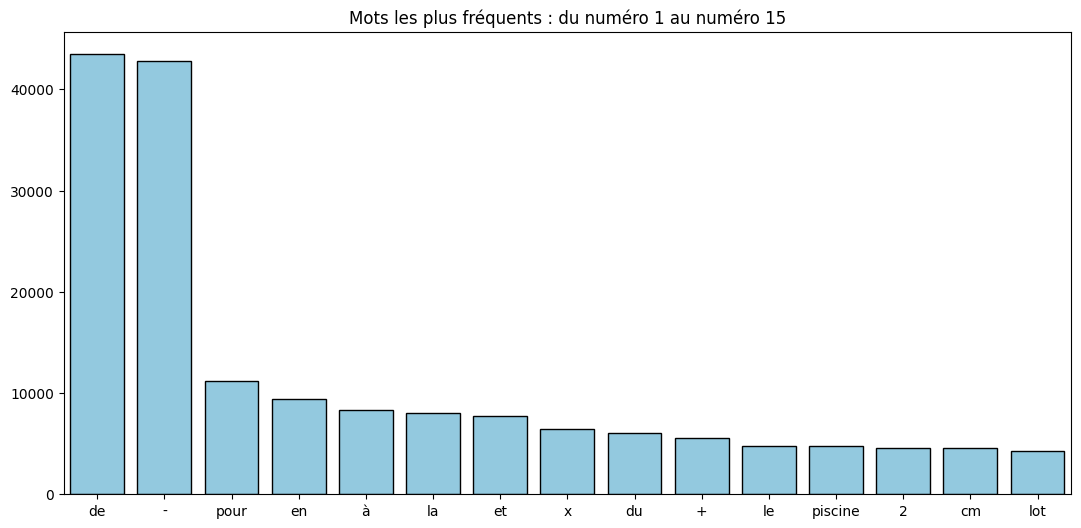

In [37]:
from collections import Counter
import seaborn as sns

dico = Counter(text.split())
first=0
amount=15
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
freq = [m[1] for m in dico.most_common(first+amount)[first:]]

plt.figure(figsize= (13,6))
sns.barplot(x=mots, y=freq, color='skyblue', edgecolor='black')
plt.title(f'Mots les plus fréquents : du numéro {first+1} au numéro {first+amount}')

In [38]:
first=0
amount=50
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'de | - | pour | en | à | la | et | x | du | + | le | piscine | 2 | cm | lot | n° | les | jeu | avec | coussin | : | des | 3 | / | 1 | m | kit | 4 | rc | taie | enfants | blanc | a | bois | led | the | décor | noël | home | & | bébé | décoration | sac | noir | jeux | bâche | bleu | drone | 5 | par'

In [39]:
first=50
amount=300
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'of | carte | mini | 6 | couverture | journal | portable | d\'oreiller | dji | acier | jouet | sur | console | mm | lampe | au | cadeau | magideal | voiture | cuisine | 10 | jardin | set | jouets | gris | spa | table | canapé | figurine | housse | pompe | carnet | coton | tapis | toy | classique | bulles | bricolage | tissu | for | support | case | ronde | rouge | maison | douche | téléchargement | 8 | peinture | vert | protection | cover | notes | intex | collection | un | 3d | 12 | super | rose | filtre | livres | quadcopter | peluche | 7 | bain | couleur | salle | bloc-notes | l | lit | stream | gonflable | oreiller | car | sans | pièces | modèle | nintendo | cahier | lumière | solaire | enfant | matelas | sofa | pro | bureau | métal | taille | edition | accueil | france | caméra | throw | papier | plastique | and | silicone | poche | rangement | 20 | pouces | pvc | accessoires | double | mode | fpv | places | tome | (le) | batterie | mavic | star | decor | magic | chaise | | | dans

#### Wordclouds

##### Initialisation

In [40]:
# Complète l'installation de nltk. Utile seulement une fois par PC.
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/val/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [41]:
from nltk.corpus import stopwords

stop_words |= set(stopwords.words('french'))
print(stop_words)

{'br', 'mon', 'ne', 'du', 'lui', 'dans', 'étés', 'serons', 'p', 'qualité', 'seraient', 'fusse', 'eûtes', 'eus', 'étant', 'facile', 'soyez', 'taille', 'fussiez', 'ayons', 'mais', 'elle', 'ton', 'aurait', 'soyons', 'soient', 'la', 'votre', 'nos', 'étions', 'eussent', 'et', 'haute', 'X', 'vos', 'div', 'de', 'sur', 'the', 'ul', 'es', 'ma', 'sera', 'tout', 'ses', 'serions', 'b', 'couleur', 'je', 't', 'êtes', 'moi', 'eurent', 'des', 'mm', '<br', 'j', 'aies', 'ou', 'avec', 'serez', 'eussions', '/>', 'sois', 'eue', 'ces', 'seriez', 'te', 'c', 'soit', 'H', 'avais', 'ils', 'aviez', 'toi', 'li', 'auras', 'vous', 'aux', 'suis', 'plus', 'être', 'ayante', 'étants', 'sa', 'serai', 'aient', 'sont', '1', 'qu', 'avaient', 'étais', 'fussions', '2', 'peut', 'avons', 'ont', 'auraient', 'étante', 'auriez', 'étiez', 'qui', 'l', 'seront', 'étaient', 'm', 'un', 'était', 'ait', 'étantes', 'fûmes', 'ayez', 'ta', 'fusses', 'pas', 'eussiez', 'd', 'ai', 'tu', 'en', 'A', 'eut', 'eûmes', 'eu', 'a', 'piscine', 'n', 'q

In [42]:
# Mieux sans masque
mask_coloring = None

In [43]:
# from PIL import Image
# path = 'images/mask.png'
# mask_coloring = np.array(Image.open(str(path)))

##### Variable : designation

In [151]:
import wordcloud
from wordcloud import WordCloud
wc1 = WordCloud(width=800, height=400, background_color="black", color_func = wordcloud.get_single_color_func('green'), mask = mask_coloring, max_words=100, max_font_size=50, stopwords=stop_words, random_state=42)

In [152]:
text = ' '.join(X.designation)
wc1.generate(text)
len(text)

6042902

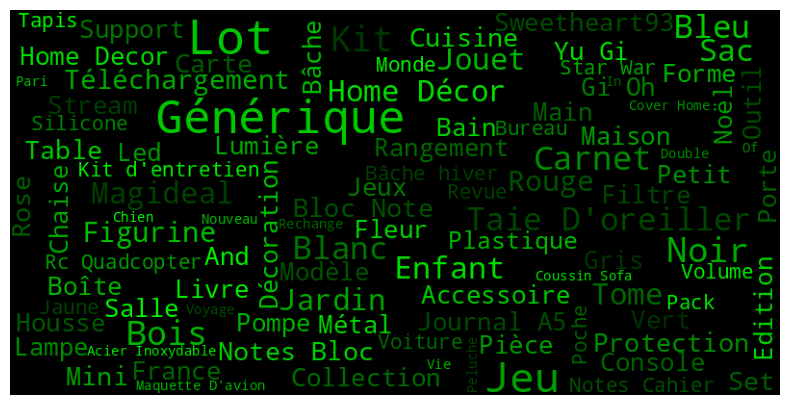

In [153]:
import matplotlib.pyplot as plt

# Générer et afficher le nuage de mots

plt.figure(figsize=(13,5))
plt.imshow(wc1)
plt.axis('off')
plt.show()

Le français semble largement majoritaire, suivi par l'anglais.

##### Variable : description

(Cellules commentées car elles mettent du temps à charger.)

In [47]:
# wc = WordCloud(width=800, height=400, background_color="black", color_func = wordcloud.get_single_color_func('green'), mask = mask_coloring, max_words=100, max_font_size=50, stopwords=stop_words, random_state=42)

In [48]:
# text = ' '.join(X.description.dropna())
# len(text)

In [49]:
# # Dure 12s.
# wc.generate(text)

In [50]:
# plt.figure(figsize=(13,5))
# plt.imshow(wc)
# plt.axis('off')
# plt.show()

### Images

#### Load

In [93]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

def load_image(row, color=True, folder = '../../Dataset/images/image_train'):
    filename = f"image_{row.imageid}_product_{row.productid}.jpg"
    path = Path(folder) / filename
    if color:
        color_arg = cv2.IMREAD_COLOR
    else:
        color_arg = cv2.IMREAD_GRAYSCALE
    img_color = cv2.imread(str(path), color_arg)
    if img_color is None:
        raise ValueError
    return img_color

#### Display

4 images sont toutes blanches.

In [ ]:
rows_with_white_image = df[df.essential_pixel_count == 0]
rows_with_white_image

,designation,description,productid,imageid,prdtypecode,len_designation,len_description,essential_pixel_count,x_min,y_min,x_max,y_max,essential_width,essential_height,aspect_ratio,essential_area
37124,Römer Britax Kid Ii Cosmos Black - Siège Auto,Römer Britax KID II Cosmos Black - Siège Auto,884747735,1142089742,1320,45,45,0,0,0,0,0,1,1,1.0,1
52327,Minions Peluche Electronique 25 Cm - Stuart,MINIONS - Retrouve l&#39;univers drôle et déja...,3793782107,1302249863,1280,43,241,0,0,0,0,0,1,1,1.0,1
79708,Blagdon extract of barley straw treatment (siz...,NaN,1892606336,1137819811,2583,57,0,0,0,0,0,0,1,1,1.0,1
80859,Bledina Mini Lactes Nature Sans Sucre - 6 X 55g,BLEDINA Mini lactes nature sans sucre - 6 x 55...,3894592691,1271791205,1940,47,279,0,0,0,0,0,1,1,1.0,1


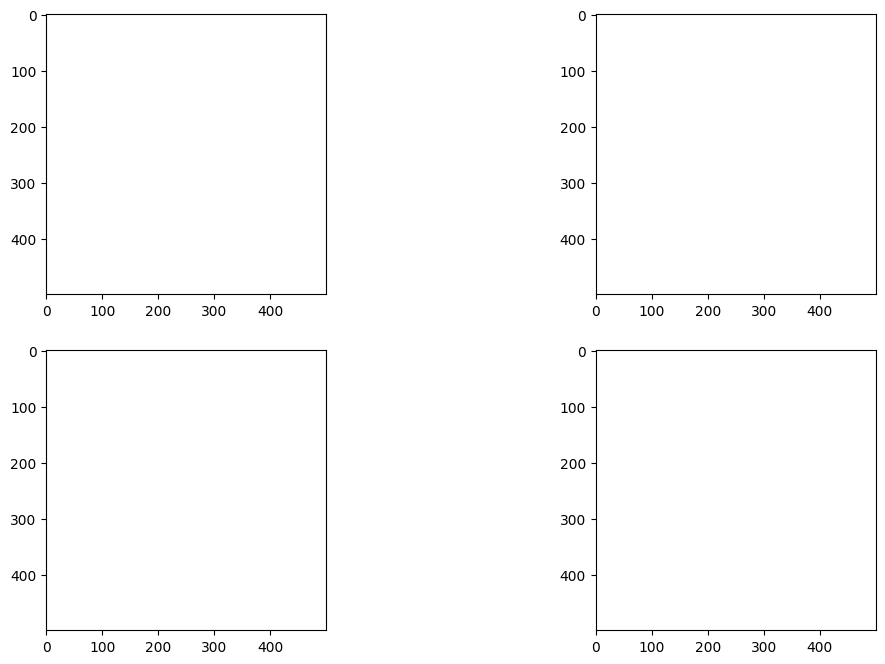

In [ ]:
display_images(rows_with_white_image,2,2,axis=True)

Show random images from the dataset.

In [122]:
def display_images(rows,nrow,ncol,axis=False):
    n = nrow*ncol
    plt.figure(figsize=(13,8))
    for k in range(n):
        plt.subplot(nrow,ncol,k+1)
        row = rows.iloc[k]
        plt.imshow(load_image(row))
        if not axis:
            plt.axis('off')

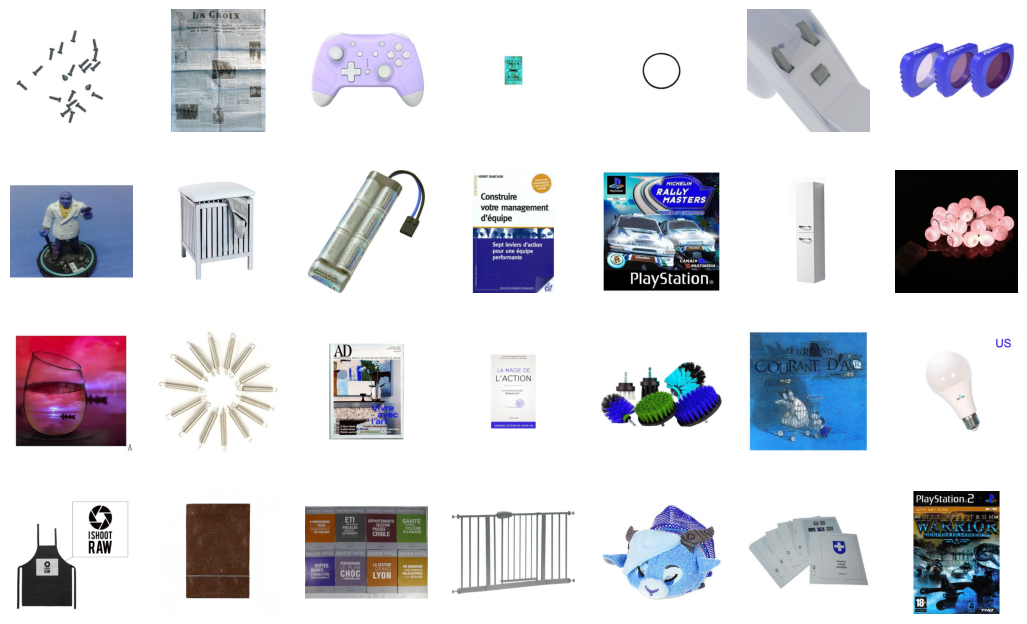

In [123]:
nrow = 4
ncol = 7
n = nrow*ncol
rows = X.sample(n)
display_images(rows,nrow,ncol)

Bien que les images aient le même nombre de pixels, certaines sur fond blanc ont des couleurs sur seulement une petite partie de l'image. On pourrait envisager de compter le nombre de pixels non blancs.

#### Pixel count

In [53]:
def count_pixels(row, product=True, ignore_white=False, folder = '../../Dataset/images/image_train'):
    img_color = load_image(row, folder = folder)
    if product:
        if ignore_white:
            non_white_pixels = img_color[(img_color[:,:,0]<255) | (img_color[:,:,1]<255) | (img_color[:,:,2]<255)]
            result = non_white_pixels.shape[0]
        else:
            result = np.prod(img_color.shape)
    else:
        result = img_color.shape
    return result

In [54]:
def count_non_white_pixels(row, folder = Path('../../Dataset/images/image_train')):
    '''Version optimisée pour cas particulier de la fonction `count_pixels`.'''
    filename = f"image_{row.imageid}_product_{row.productid}.jpg"
    path = folder / filename
    img_color = cv2.imread(str(path), cv2.IMREAD_COLOR)
    non_white_pixels = img_color[(img_color[:,:,0]<255) | (img_color[:,:,1]<255) | (img_color[:,:,2]<255)]
    return non_white_pixels.shape[0]

On regarde les dimensions d'images aléatoires du jeu de données. (Regarder toutes les images met longtemps à charger.) Elles ont toutes les mêmes dimensions.

In [55]:
X.sample(100).apply(count_pixels,axis=1,args=(False,)).unique()

array([(500, 500, 3)], dtype=object)

In [56]:
X.sample(100).apply(count_pixels,axis=1,args=(True,)).unique()

array([750000])

In [ ]:
# # Regarde pour toutes les lignes, donc met 2m30 à charger. Résultat : array([(500, 500, 3)], dtype=object).
# X.apply(count_pixels,axis=1,args=(False,)).unique()

On compte maintenant les pixels non blancs.

In [39]:
sorted(X.iloc[:100].apply(count_non_white_pixels,axis=1).unique())

[np.int64(4147),
 np.int64(13190),
 np.int64(23346),
 np.int64(24629),
 np.int64(30197),
 np.int64(30224),
 np.int64(30897),
 np.int64(39351),
 np.int64(40387),
 np.int64(40478),
 np.int64(43366),
 np.int64(45079),
 np.int64(45681),
 np.int64(50401),
 np.int64(51612),
 np.int64(56387),
 np.int64(57853),
 np.int64(61385),
 np.int64(62728),
 np.int64(63281),
 np.int64(63368),
 np.int64(65499),
 np.int64(73281),
 np.int64(75958),
 np.int64(76723),
 np.int64(83947),
 np.int64(85538),
 np.int64(91078),
 np.int64(95850),
 np.int64(97740),
 np.int64(98127),
 np.int64(100791),
 np.int64(104011),
 np.int64(107123),
 np.int64(108428),
 np.int64(108774),
 np.int64(117108),
 np.int64(121146),
 np.int64(122326),
 np.int64(125489),
 np.int64(125506),
 np.int64(125587),
 np.int64(126323),
 np.int64(128211),
 np.int64(130559),
 np.int64(131717),
 np.int64(133126),
 np.int64(134675),
 np.int64(139414),
 np.int64(140320),
 np.int64(142118),
 np.int64(143581),
 np.int64(144929),
 np.int64(145764),
 np.in

In [25]:
X.iloc[:100].apply(count_non_white_pixels,axis=1).unique().shape

(96,)

In [ ]:
# # Regarde pour toutes les lignes, donc met 5m30 à charger.
# pixel_counts = X.apply(count_non_white_pixels,axis=1)

In [ ]:
# sorted(pixel_counts[:100].unique())

[np.int64(4147),
 np.int64(13190),
 np.int64(23346),
 np.int64(24629),
 np.int64(30197),
 np.int64(30224),
 np.int64(30897),
 np.int64(39351),
 np.int64(40387),
 np.int64(40478),
 np.int64(43366),
 np.int64(45079),
 np.int64(45681),
 np.int64(50401),
 np.int64(51612),
 np.int64(56387),
 np.int64(57853),
 np.int64(61385),
 np.int64(62728),
 np.int64(63281),
 np.int64(63368),
 np.int64(65499),
 np.int64(73281),
 np.int64(75958),
 np.int64(76723),
 np.int64(83947),
 np.int64(85538),
 np.int64(91078),
 np.int64(95850),
 np.int64(97740),
 np.int64(98127),
 np.int64(100791),
 np.int64(104011),
 np.int64(107123),
 np.int64(108428),
 np.int64(108774),
 np.int64(117108),
 np.int64(121146),
 np.int64(122326),
 np.int64(125489),
 np.int64(125506),
 np.int64(125587),
 np.int64(126323),
 np.int64(128211),
 np.int64(130559),
 np.int64(131717),
 np.int64(133126),
 np.int64(134675),
 np.int64(139414),
 np.int64(140320),
 np.int64(142118),
 np.int64(143581),
 np.int64(144929),
 np.int64(145764),
 np.in

In [ ]:
# pixel_counts.shape

(84916,)

In [ ]:
# path = 'np/pixel_counts.npy'
# np.save(path, pixel_counts)

In [70]:
path = 'np/pixel_counts.npy'
pixel_counts = np.load(path)

In [71]:
pixel_counts

array([ 30197,  51612,  23346, ...,  59119, 144441, 149527],
      shape=(84916,))

In [87]:
df['essential_pixel_count']=pixel_counts

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   designation            84916 non-null  object
 1   description            55116 non-null  object
 2   productid              84916 non-null  int64 
 3   imageid                84916 non-null  int64 
 4   prdtypecode            84916 non-null  int64 
 5   len_designation        84916 non-null  int64 
 6   len_description        84916 non-null  int64 
 7   essential_pixel_count  84916 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 7.8+ MB


In [90]:
df.head()

,designation,description,productid,imageid,prdtypecode,len_designation,len_description,essential_pixel_count
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10,88,0,30197
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280,206,0,51612
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,76,760,23346
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280,63,0,134675
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705,20,213,57853


#### Various image features

In [91]:
def get_content_bounding_box(row, folder = '../../Dataset/images/image_train'):
    # Load image, ensure it's grayscale for finding coordinates
    img = load_image(row, color=False, folder = folder)
    if img is None:
        return None # Handle case where image doesn't load

    # Find all non-white pixels. A threshold of 254 handles JPEG artifacts.
    # (Pure white is 255, but compression can create values like 254)
    non_white_pixels = np.argwhere(img < 254) # Returns (row, col) coordinates

    if non_white_pixels.size == 0:
        return 0, 0, 0, 0 # No content, return zero box

    # np.argwhere gives (row, col) which corresponds to (y, x)
    y_coords = non_white_pixels[:, 0]
    x_coords = non_white_pixels[:, 1]

    y_min, y_max = y_coords.min(), y_coords.max()
    x_min, x_max = x_coords.min(), x_coords.max()

    return x_min, y_min, x_max, y_max

In [96]:
coords = df.apply(get_content_bounding_box,axis=1)

In [100]:
coords

0        (176, 144, 319, 351)
1        (160, 112, 343, 383)
2          (72, 64, 425, 431)
3          (80, 56, 415, 447)
4         (160, 96, 343, 399)
                 ...         
84911       (72, 0, 431, 499)
84912       (0, 56, 499, 439)
84913    (144, 112, 351, 391)
84914      (17, 56, 479, 439)
84915      (0, 104, 499, 399)
Length: 84916, dtype: object

In [101]:
col_names = ['x_min', 'y_min', 'x_max', 'y_max']
coords_df = pd.DataFrame(coords.tolist(), index=df.index, columns=col_names)
coords_df

,x_min,y_min,x_max,y_max
0,176,144,319,351
1,160,112,343,383
2,72,64,425,431
3,80,56,415,447
4,160,96,343,399
...,...,...,...,...
84911,72,0,431,499
84912,0,56,499,439
84913,144,112,351,391
84914,17,56,479,439


In [105]:
df = df.join(coords_df)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   designation            84916 non-null  object
 1   description            55116 non-null  object
 2   productid              84916 non-null  int64 
 3   imageid                84916 non-null  int64 
 4   prdtypecode            84916 non-null  int64 
 5   len_designation        84916 non-null  int64 
 6   len_description        84916 non-null  int64 
 7   essential_pixel_count  84916 non-null  int64 
 8   x_min                  84916 non-null  int64 
 9   y_min                  84916 non-null  int64 
 10  x_max                  84916 non-null  int64 
 11  y_max                  84916 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 10.4+ MB


In [139]:
df['essential_width'] = df.x_max - df.x_min + 1

In [140]:
df['essential_height'] = df.y_max - df.y_min + 1

In [141]:
df['aspect_ratio'] = df.essential_width / df.essential_height

In [142]:
df['essential_area'] = df.essential_width * df.essential_height

In [147]:
df['essential_density'] = df.essential_pixel_count / df.essential_area

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   designation            84916 non-null  object 
 1   description            55116 non-null  object 
 2   productid              84916 non-null  int64  
 3   imageid                84916 non-null  int64  
 4   prdtypecode            84916 non-null  int64  
 5   len_designation        84916 non-null  int64  
 6   len_description        84916 non-null  int64  
 7   essential_pixel_count  84916 non-null  int64  
 8   x_min                  84916 non-null  int64  
 9   y_min                  84916 non-null  int64  
 10  x_max                  84916 non-null  int64  
 11  y_max                  84916 non-null  int64  
 12  essential_width        84916 non-null  int64  
 13  essential_height       84916 non-null  int64  
 14  aspect_ratio           84916 non-null  float64
 15  essenti

Les variables essential_area et essential_pixel_count ne sont pas redondantes.

In [149]:
df['essential_density'].describe()

count    84916.000000
mean         0.851534
std          0.229848
min          0.000000
25%          0.700356
50%          0.971666
75%          1.008360
max         10.838845
Name: essential_density, dtype: float64

In [145]:
df[df.essential_area.isna()]

,designation,description,productid,imageid,prdtypecode,len_designation,len_description,essential_pixel_count,x_min,y_min,x_max,y_max,essential_width,essential_height,aspect_ratio,essential_area


In [150]:
df['essential_density'].fillna(0).describe()

count    84916.000000
mean         0.851534
std          0.229848
min          0.000000
25%          0.700356
50%          0.971666
75%          1.008360
max         10.838845
Name: essential_density, dtype: float64